In [3]:
import argparse
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F

from tqdm import trange

sys.path.insert(1, "/".join(os.path.abspath("").split("/")[0:-1]))

import models

from importlib import reload

reload(models)

<module 'models' from '/coc/flash12/cli726/_PoissonGradEstim/main/poglm/models.py'>

In [6]:
n_vis_neurons = 3
n_hid_neurons = 2
kernel_size = 3
n_time_bins = 100
n_samples_train = 40
n_samples_test = 20
n_trials = 10

In [11]:
df = pd.DataFrame(
    index=np.arange(n_trials),
    columns=[
        "model",
        "y_train",
        "rate_train",
        "y_test",
        "rate_test",
    ],
)

for trial in trange(n_trials):
    poglm = models.POGLM(
        n_vis_neurons=n_vis_neurons,
        n_hid_neurons=n_hid_neurons,
        kernel_size=kernel_size,
    )

    with torch.inference_mode():
        poglm.conv_generative.data = (
            torch.randn(poglm.conv_generative.weight.shape) * 0.5
        )
        poglm.conv_generative.bias.data = (
            torch.randn(poglm.conv_generative.bias.shape) * 0.5
        )

    rate_train, y_train = poglm.sample(n_time_bins, n_samples_train)
    rate_test, y_test = poglm.sample(n_time_bins, n_samples_test)

    df.at[trial, "model"] = poglm.state_dict()
    df.at[trial, "y_train"] = y_train
    df.at[trial, "rate_train"] = rate_train
    df.at[trial, "y_test"] = y_test
    df.at[trial, "rate_test"] = rate_test

100%|██████████| 10/10 [00:00<00:00, 25.31it/s]


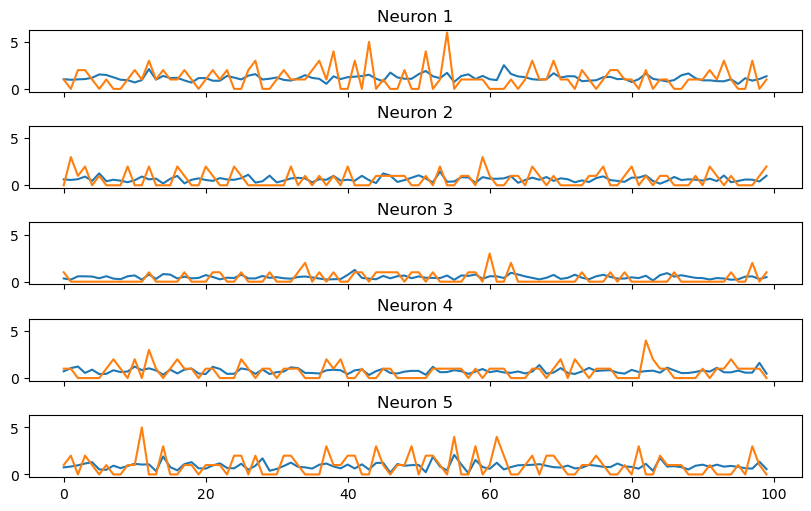

In [22]:
trial = 0
sample = 2

rate_train = df.at[trial, "rate_train"]
y_train = df.at[trial, "y_train"]

fig, axs = plt.subplots(
    n_neurons,
    1,
    figsize=(8, n_neurons),
    layout="constrained",
    sharex=True,
    sharey=True,
)
for i in range(n_neurons):
    axs[i].plot(rate_train[sample, :, i].numpy(), color="C0")
    axs[i].plot(
        y_train[sample, :, i].numpy(),
        color="C1",
    )
    axs[i].set_title(f"Neuron {i+1}")

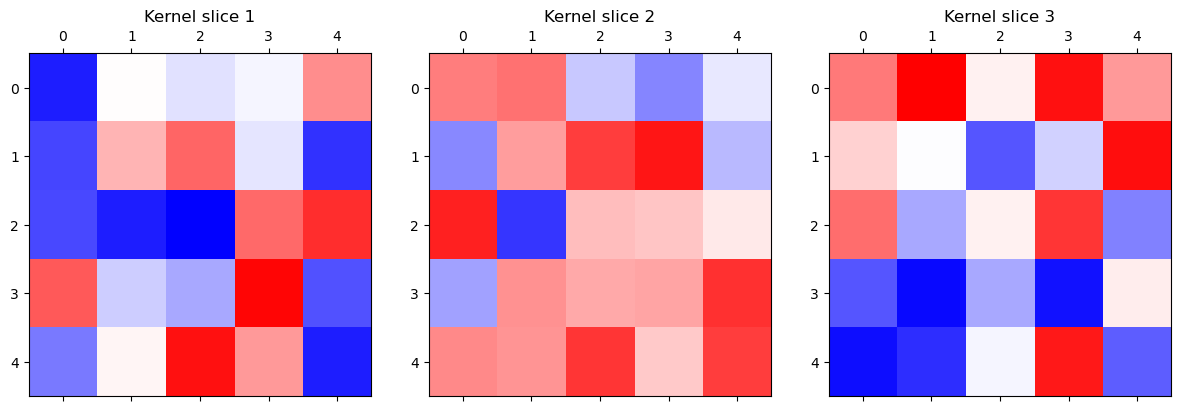

In [ ]:
fig, axs = plt.subplots(1, kernel_size, figsize=(12, 4), layout="constrained")

for k in range(kernel_size):
    axs[k].matshow(
        poglm.conv_generative.weight[:, :, k].detach().numpy(),
        cmap="seismic",
        vmin=-0.5,
        vmax=0.5,
    )
    axs[k].set_title(f"Kernel slice {k+1}")

In [28]:
df.to_pickle("data.pkl")

In [30]:
df.at[0, "y_train"].shape

torch.Size([40, 100, 5])

In [36]:
from itertools import permutations

all_possible_permutations = torch.tensor(list(permutations(range(3))))
n_possible_permutations = all_possible_permutations.shape[0]
all_possible_permutations = torch.cat(
    (
        torch.arange(2).unsqueeze(0).expand(n_possible_permutations, -1),
        all_possible_permutations + 2,
    ),
    dim=1,
)

In [37]:
all_possible_permutations

tensor([[0, 1, 2, 3, 4],
        [0, 1, 2, 4, 3],
        [0, 1, 3, 2, 4],
        [0, 1, 3, 4, 2],
        [0, 1, 4, 2, 3],
        [0, 1, 4, 3, 2]])

In [39]:
df.at[0, "model"]["conv_generative.weight"]

tensor([[[ 0.0748, -0.0876, -0.0871],
         [ 0.0934,  0.0251, -0.2002],
         [-0.1722,  0.1774, -0.1159],
         [-0.1374, -0.0735, -0.1239],
         [ 0.1770,  0.2236,  0.2269]],

        [[ 0.0138,  0.1191, -0.1072],
         [-0.1268,  0.2564, -0.0524],
         [ 0.0944, -0.0082, -0.0385],
         [ 0.0628, -0.2560, -0.1239],
         [-0.2572,  0.1978,  0.1360]],

        [[ 0.0617, -0.0111, -0.2404],
         [-0.0587, -0.0084,  0.1502],
         [ 0.1535, -0.0976, -0.1663],
         [ 0.2263,  0.1856, -0.2388],
         [ 0.2258,  0.0689,  0.1407]],

        [[-0.0832, -0.1050,  0.1305],
         [-0.1360, -0.1198,  0.2265],
         [-0.0419, -0.1847,  0.0957],
         [ 0.0024,  0.0005,  0.1139],
         [-0.0698, -0.1515,  0.2404]],

        [[-0.2480,  0.0547,  0.1729],
         [-0.1429,  0.1378,  0.0954],
         [ 0.2188, -0.0907, -0.1060],
         [-0.0086,  0.1864, -0.0074],
         [ 0.1622, -0.2471,  0.1008]]])

In [44]:
poglm.conv_generative.weight.data[3:, 3:, :] = poglm.conv_generative.weight.data[
    [4, 3], 3:, :
][3:, [4, 3], :]

RuntimeError: The expanded size of the tensor (2) must match the existing size (0) at non-singleton dimension 0.  Target sizes: [2, 2, 3].  Tensor sizes: [0, 2, 3]

In [54]:
poglm.conv_generative.weight.data[[0, 1, 2, 4, 3], :, :][:, [0, 1, 2, 4, 3], :].shape

torch.Size([5, 5, 3])